Kiểm tra GPU

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Không có, sẽ chạy bằng CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Import thư viện

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

Thiết lập device và seed

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Using device: cuda


Tải bộ dữ liệu MNIST

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Số ảnh train ban đầu:", len(train_full_dataset))
print("Số ảnh test:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.35MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.11MB/s]

Số ảnh train ban đầu: 60000
Số ảnh test: 10000


Chia train và validation

In [ ]:
val_size = int(0.1 * len(train_full_dataset))
train_size = len(train_full_dataset) - val_size

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Số ảnh train:", len(train_dataset))
print("Số ảnh validation:", len(val_dataset))
print("Số ảnh test:", len(test_dataset))

Số ảnh train: 54000
Số ảnh validation: 6000
Số ảnh test: 10000


Xây dựng mô hình CNN + Batch Normalization

In [ ]:
class CNNBatchNormModel(nn.Module):
    def __init__(self):
        super(CNNBatchNormModel, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.bn3(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


model = CNNBatchNormModel().to(device)
print(model)

CNNBatchNormModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Khai báo loss function và optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Viết hàm train và evaluate

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Train mô hình

In [ ]:
epochs = 10
patience = 3

best_val_loss = float("inf")
best_val_acc = 0.0
patience_counter = 0

history = {
    "accuracy": [],
    "val_accuracy": [],
    "loss": [],
    "val_loss": []
}

best_model_path = "best_cnn_batchnorm_mnist_pytorch.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    # Lưu model tốt nhất theo validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("  -> Đã lưu model tốt nhất theo val_accuracy")

    # Early stopping theo validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  -> Validation loss không cải thiện. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Dừng sớm vì validation loss không cải thiện thêm.")
            break

# Load lại model tốt nhất
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

print("Đã load lại model tốt nhất.")

Epoch [1/10] Train Loss: 0.1748 | Train Acc: 0.9621 | Val Loss: 0.0561 | Val Acc: 0.9842
  -> Đã lưu model tốt nhất theo val_accuracy
Epoch [2/10] Train Loss: 0.0594 | Train Acc: 0.9838 | Val Loss: 0.0392 | Val Acc: 0.9883
  -> Đã lưu model tốt nhất theo val_accuracy
Epoch [3/10] Train Loss: 0.0428 | Train Acc: 0.9876 | Val Loss: 0.0355 | Val Acc: 0.9892
  -> Đã lưu model tốt nhất theo val_accuracy
Epoch [4/10] Train Loss: 0.0348 | Train Acc: 0.9902 | Val Loss: 0.0319 | Val Acc: 0.9902
  -> Đã lưu model tốt nhất theo val_accuracy
Epoch [5/10] Train Loss: 0.0269 | Train Acc: 0.9922 | Val Loss: 0.0315 | Val Acc: 0.9903
  -> Đã lưu model tốt nhất theo val_accuracy
Epoch [6/10] Train Loss: 0.0235 | Train Acc: 0.9928 | Val Loss: 0.0328 | Val Acc: 0.9910
  -> Đã lưu model tốt nhất theo val_accuracy
  -> Validation loss không cải thiện. Patience: 1/3
Epoch [7/10] Train Loss: 0.0202 | Train Acc: 0.9941 | Val Loss: 0.0306 | Val Acc: 0.9920
  -> Đã lưu model tốt nhất theo val_accuracy
Epoch [8/1

Đánh giá trên tập test

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.022644244698011608
Test Accuracy: 0.9929


Vẽ biểu đồ Accuracy

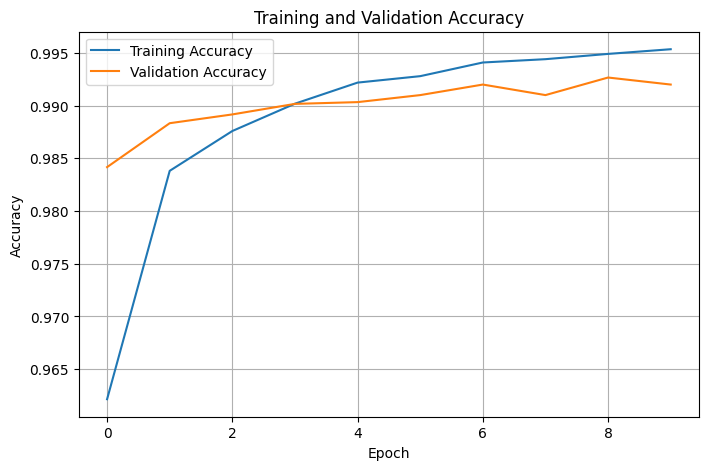

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Vẽ biểu đồ Loss

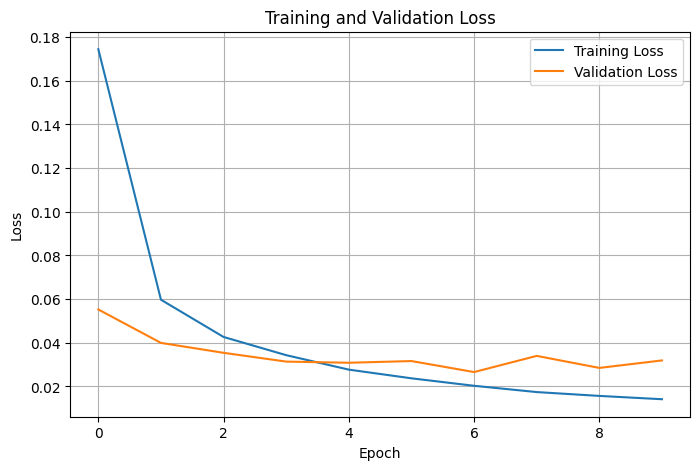

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

dự đoán thử 1 ảnh

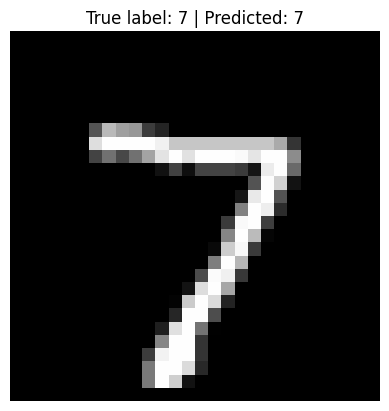

Prediction probabilities: [[5.6087499e-09 2.6078846e-08 1.6697625e-08 1.3029006e-07 1.3700809e-09
  6.2633889e-09 6.2300456e-11 9.9999964e-01 5.9107103e-10 2.5025437e-07]]


In [ ]:
index = 0

image, true_label = test_dataset[index]
input_image = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_image)
    probabilities = F.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"True label: {true_label} | Predicted: {predicted_label}")
plt.axis("off")
plt.show()

print("Prediction probabilities:", probabilities.cpu().numpy())

Tạo Confusion Matrix và Classification Report

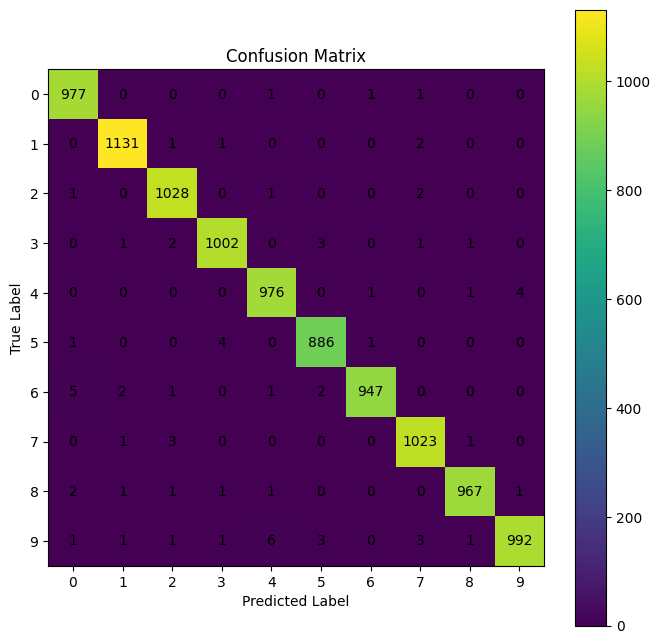

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

print(classification_report(y_true, y_pred))

Dự đoán mẫu đúng và sai

/tmp/ipykernel_1131/3491496908.py:84: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1131/3491496908.py:84: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1131/3491496908.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("sample_predictions.png", dpi=150)
/tmp/ipykernel_1131/3491496908.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("sample_predictions.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

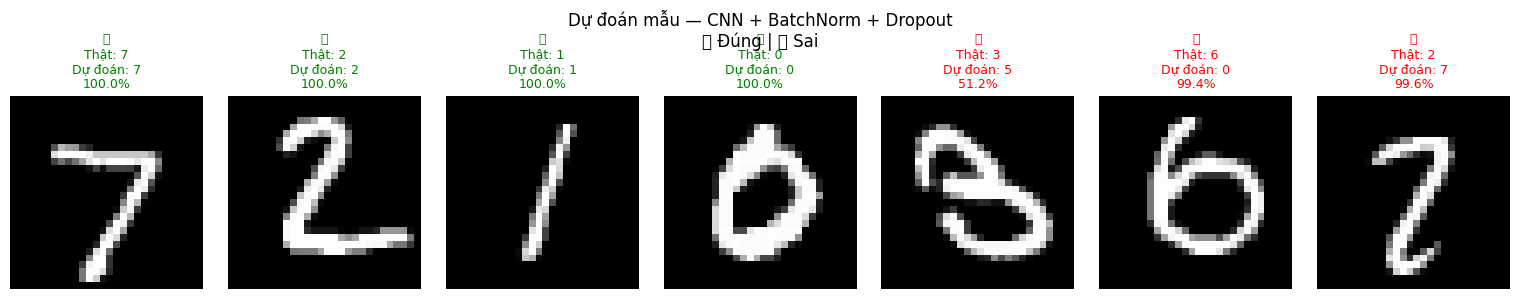

In [ ]:
# ==============================
# Dự đoán mẫu đúng và sai
# ==============================

model.eval()

correct_images = []
correct_labels = []
correct_preds = []
correct_probs = []

wrong_images = []
wrong_labels = []
wrong_preds = []
wrong_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images_device = images.to(device)

        outputs = model(images_device)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = preds[i].item()
            pred_prob = probs[i][pred_label].item() * 100

            if true_label == pred_label and len(correct_images) < 4:
                correct_images.append(images[i])
                correct_labels.append(true_label)
                correct_preds.append(pred_label)
                correct_probs.append(pred_prob)

            elif true_label != pred_label and len(wrong_images) < 3:
                wrong_images.append(images[i])
                wrong_labels.append(true_label)
                wrong_preds.append(pred_label)
                wrong_probs.append(pred_prob)

        if len(correct_images) >= 4 and len(wrong_images) >= 3:
            break

show_images = correct_images + wrong_images
show_labels = correct_labels + wrong_labels
show_preds = correct_preds + wrong_preds
show_probs = correct_probs + wrong_probs

if len(wrong_images) < 3:
    print(f"⚠️ Chỉ tìm thấy {len(wrong_images)} ảnh sai trong tập test.")
    print("Model dự đoán khá tốt nên số ảnh sai có thể rất ít.")

num_images = len(show_images)

fig, axes = plt.subplots(1, num_images, figsize=(2.2 * num_images, 3))

if num_images == 1:
    axes = [axes]

fig.suptitle(
    "Dự đoán mẫu — CNN + BatchNorm + Dropout\n✅ Đúng | ❌ Sai",
    fontsize=12
)

for i in range(num_images):
    img = show_images[i].squeeze().numpy()
    true = show_labels[i]
    pred = show_preds[i]
    prob = show_probs[i]

    is_ok = true == pred
    mark = "✅" if is_ok else "❌"
    color = "green" if is_ok else "red"

    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(
        f"{mark}\nThật: {true}\nDự đoán: {pred}\n{prob:.1f}%",
        color=color,
        fontsize=9
    )

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()

Lưu model cuối cùng và in thông tin

In [ ]:
# ==============================
# Lưu model cuối cùng
# ==============================

final_model_path = "CNN_BatchNorm_final.pt"

torch.save(model.state_dict(), final_model_path)

print("──────────────── THÔNG TIN LƯU MODEL ────────────────")
print(f" Tên file        : {final_model_path}")
print(f" Định dạng       : PyTorch state_dict (.pt)")
print(f" Val Loss tốt    : {best_val_loss:.4f}")
print(f" Test Accuracy   : {test_acc * 100:.2f}%")
print(f" Mô hình         : CNN + BatchNorm + Dropout")
print(f" Dùng cho demo   : Dự đoán chữ số viết tay MNIST")

──────────────── THÔNG TIN LƯU MODEL ────────────────
 Tên file        : CNN_BatchNorm_final.pt
 Định dạng       : PyTorch state_dict (.pt)
 Val Loss tốt    : 0.0299
 Test Accuracy   : 99.29%
 Mô hình         : CNN + BatchNorm + Dropout
 Dùng cho demo   : Dự đoán chữ số viết tay MNIST


In [ ]:
import os, glob

print(glob.glob("**/*.pth", recursive=True))
print(os.path.exists("best_cnn_batchnorm_mnist_pytorch.pth"))

['best_cnn_batchnorm_mnist_pytorch.pth']
True


In [ ]:
from google.colab import files

files.download("best_cnn_batchnorm_mnist_pytorch.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNBatchNormModel(nn.Module):
    def __init__(self):
        super(CNNBatchNormModel, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.bn3(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)

        return x
'''

with open("CNN_BatchNorm_model.py", "w", encoding="utf-8") as f:
    f.write(model_code)

print("Đã tạo file CNN_BatchNorm_model.py")

Đã tạo file CNN_BatchNorm_model.py


In [ ]:
import os, glob

print(glob.glob("*.py"))
print(os.path.exists("CNN_BatchNorm_model.py"))

['CNN_BatchNorm_model.py']
True


In [ ]:
import torch
from CNN_BatchNorm_model import CNNBatchNormModel

model = CNNBatchNormModel()

state_dict = torch.load(
    "best_cnn_batchnorm_mnist_pytorch.pth",
    map_location="cpu"
)

model.load_state_dict(state_dict)
model.eval()

print("Load model thành công!")

Load model thành công!


In [ ]:
from google.colab import files

files.download("CNN_BatchNorm_model.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>